In [1]:
!pip install pyspark

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("MovieLens_HW").getOrCreate()
print("Spark è pronto!")

Spark è pronto!


In [2]:
# Scarico il file zip direttamente dal sito di GroupLens
!wget https://files.grouplens.org/datasets/movielens/ml-25m.zip

!unzip ml-25m.zip
print("Dati scaricati e decompressi con successo!")

--2026-05-13 13:26:03--  https://files.grouplens.org/datasets/movielens/ml-25m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 261978986 (250M) [application/zip]
Saving to: ‘ml-25m.zip’

ml-25m.zip          100%[===================>] 249.84M  10.9MB/s    in 19s     

2026-05-13 13:26:23 (13.0 MB/s) - ‘ml-25m.zip’ saved [261978986/261978986]

Archive:  ml-25m.zip
   creating: ml-25m/
  inflating: ml-25m/tags.csv         
  inflating: ml-25m/links.csv        
  inflating: ml-25m/README.txt       
  inflating: ml-25m/ratings.csv      
  inflating: ml-25m/genome-tags.csv  
  inflating: ml-25m/genome-scores.csv  
  inflating: ml-25m/movies.csv       
Dati scaricati e decompressi con successo!


In [3]:
# Leggiamo i file CSV
movies_df = spark.read.csv("ml-25m/movies.csv", header=True, inferSchema=True)
ratings_df = spark.read.csv("ml-25m/ratings.csv", header=True, inferSchema=True)

# Analizziamo i primi 5 film
movies_df.show(5, truncate=False)

+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|5      |Father of the Bride Part II (1995)|Comedy                                     |
+-------+----------------------------------+-------------------------------------------+
only showing top 5 rows


La traccia chiede di calcolare per ogni genere il numero totale di rating, la media, la mediana e la deviazione standard, per poi ordinare tutto in modo decrescente in base alla media.

Per farlo useremo alcune funzioni speciali di Spark.Visto che un film può avere più generi scritti insieme (es. "Action|Adventure"), useremo una funzione per "sdoppiare" la riga del film creando una riga per ogni genere separato, così possiamo raggrupparli correttamente.

In [4]:
from pyspark.sql.functions import col, split, explode, count, avg, stddev, percentile_approx, round

# 1. "Esplodiamo" i generi separandoli dal simbolo |
movies_exploded = movies_df.withColumn("genre", explode(split(col("genres"), "\|")))

# 2. Uniamo i voti con i film usando la colonna in comune "movieId"
joined_df = ratings_df.join(movies_exploded, "movieId")

# 3. Creiamo i raggruppamenti per genere e calcoliamo le statistiche
risultato_1_1 = joined_df.groupBy("genre").agg(
    count("rating").alias("numero_rating"),
    round(avg("rating"), 2).alias("rating_medio"),
    percentile_approx("rating", 0.5).alias("mediana"), # percentile_approx a 0.5 calcola la mediana
    round(stddev("rating"), 2).alias("deviazione_standard")
)

# 4. Ordiniamo per rating medio decrescente
risultato_finale = risultato_1_1.orderBy(col("rating_medio").desc())

# 5. Mostriamo i primi 20 risultati
risultato_finale.show()


<>:4: SyntaxWarning: invalid escape sequence '\|'
<>:4: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_5956/2303940055.py:4: SyntaxWarning: invalid escape sequence '\|'
  movies_exploded = movies_df.withColumn("genre", explode(split(col("genres"), "\|")))


+------------------+-------------+------------+-------+-------------------+
|             genre|numero_rating|rating_medio|mediana|deviazione_standard|
+------------------+-------------+------------+-------+-------------------+
|         Film-Noir|       247227|        3.93|    4.0|               0.91|
|               War|      1267346|        3.79|    4.0|               0.99|
|       Documentary|       322449|        3.71|    4.0|               1.02|
|             Crime|      4190259|        3.69|    4.0|               1.01|
|             Drama|     10962833|        3.68|    4.0|                1.0|
|           Mystery|      2010995|        3.67|    4.0|               1.01|
|         Animation|      1630987|        3.61|    4.0|               1.04|
|              IMAX|      1063279|         3.6|    4.0|               1.05|
|           Western|       483731|        3.59|    4.0|               1.02|
|           Musical|       964252|        3.55|    4.0|               1.06|
|           

PUNTO 1.1.2

--- I 3 MESI CON IL RATING MEDIO PIÙ ALTO ---
+---------+------------+
|anno_mese|rating_medio|
+---------+------------+
|  1996-01|        4.17|
|  1996-03|        3.93|
|  1996-04|         3.8|
+---------+------------+

--- I 3 MESI CON IL RATING MEDIO PIÙ BASSO ---
+---------+------------+
|anno_mese|rating_medio|
+---------+------------+
|  2010-03|        3.36|
|  2004-08|        3.36|
|  2002-08|        3.37|
+---------+------------+



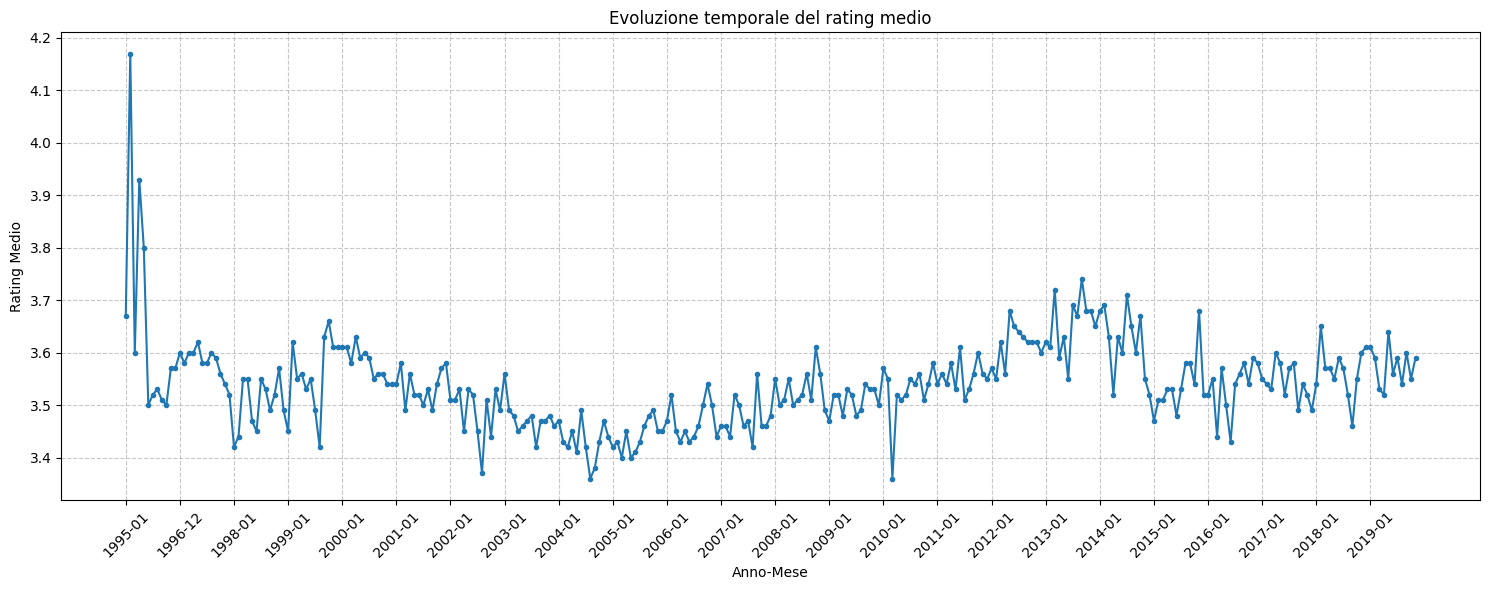

In [5]:
from pyspark.sql.functions import col, from_unixtime, date_format, avg, round
import matplotlib.pyplot as plt

ratings_con_data = ratings_df.withColumn("anno_mese", date_format(from_unixtime(col("timestamp")), "yyyy-MM"))

media_mensile = ratings_con_data.groupBy("anno_mese").agg(
    round(avg("rating"), 2).alias("rating_medio")
)

top_3_mesi = media_mensile.orderBy(col("rating_medio").desc()).limit(3)
bottom_3_mesi = media_mensile.orderBy(col("rating_medio").asc()).limit(3)

print("--- I 3 MESI CON IL RATING MEDIO PIÙ ALTO ---")
top_3_mesi.show()

print("--- I 3 MESI CON IL RATING MEDIO PIÙ BASSO ---")
bottom_3_mesi.show()

andamento_completo = media_mensile.orderBy("anno_mese")

andamento_pd = andamento_completo.toPandas()

plt.figure(figsize=(15, 6))
plt.plot(andamento_pd['anno_mese'], andamento_pd['rating_medio'], marker='.', linestyle='-')
plt.xticks(andamento_pd['anno_mese'][::12], rotation=45)
plt.title('Evoluzione temporale del rating medio')
plt.xlabel('Anno-Mese')
plt.ylabel('Rating Medio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

PUNTO 1.1.3


In [6]:
from pyspark.sql.functions import col, avg, count, round, lit, percentile_approx

# 1. Calcoliamo il rating medio di tutto il dataset
media_globale_row = ratings_df.agg(avg("rating").alias("globale")).collect()[0]
media_globale = media_globale_row["globale"]

# 2. Calcoliamo numero di rating e media per ogni utente
utenti_stats = ratings_df.groupBy("userId").agg(
    count("rating").alias("numero_rating"),
    avg("rating").alias("rating_medio_personale")
)

# 3. Identifichiamo la soglia per il top 5% (95-esimo percentile)
soglia_row = utenti_stats.agg(percentile_approx("numero_rating", 0.95).alias("soglia")).collect()[0]
soglia_top_5 = soglia_row["soglia"]

# 4. Filtriamo solo gli utenti sopra la soglia e calcoliamo il bias
risultato_1_1_3 = utenti_stats.filter(col("numero_rating") >= soglia_top_5) \
    .withColumn("rating_medio_personale", round(col("rating_medio_personale"), 2)) \
    .withColumn("bias_personale", round(col("rating_medio_personale") - lit(media_globale), 2)) \
    .orderBy(col("numero_rating").desc())

print(f"Media globale del dataset: {media_globale:.2f}")
print(f"Soglia minima di voti per essere nel top 5%: {soglia_top_5}")
risultato_1_1_3.show()

Media globale del dataset: 3.53
Soglia minima di voti per essere nel top 5%: 554
+------+-------------+----------------------+--------------+
|userId|numero_rating|rating_medio_personale|bias_personale|
+------+-------------+----------------------+--------------+
| 72315|        32202|                  3.08|         -0.45|
| 80974|         9178|                  3.28|         -0.25|
|137293|         8913|                  3.18|         -0.35|
| 33844|         7919|                  2.58|         -0.95|
| 20055|         7488|                  3.21|         -0.32|
|109731|         6647|                  2.82|         -0.71|
| 92046|         6564|                  3.48|         -0.05|
| 49403|         6553|                  1.52|         -2.01|
| 30879|         5693|                  2.88|         -0.65|
|115102|         5649|                  2.46|         -1.07|
|110971|         5633|                  3.75|          0.22|
| 75309|         5525|                   5.0|          1.47|
| 78